## 1. 设置、参数与库导入

In [1]:
IS_SERVER = True
FORCE_CPU = False


# --- 实验参数配置 ---
class Args:
    # 基本设置
    name = "ResNet-18-CIFAR100-Baseline-nozero"
    gpu = 0
    seed = 42

    # 数据集参数
    workers = 1
    is_weighted = False

    num_classes = 100

    # 训练参数
    epochs = 200
    batch_size = 128
    lr = 1.5e-3
    min_lr = 1e-5
    warmup_epochs = 20
    amp = True  # 是否使用自动混合精度训练

    # 数据增强与正则（对齐 MaxFormer 的 CIFAR100 配置）
    use_mixup = True
    use_randaugment = True
    use_random_erasing = True
    mixup_alpha = 0.75
    cutmix_alpha = 0.5
    label_smoothing = 0.1
    random_erasing_prob = 0.25
    randaugment_config = "rand-m9-n1-mstd0.4-inc1"

    # 优化器参数
    opt = "adamw"
    momentum = 0.9
    weight_decay = 0.06
    scheduler = "cosine_warmup"
    cos_lr_T = 200


args = Args()

import os

import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

# 导入核心库
import torch
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter

from tqdm import tqdm
import datetime
import numpy as np
import random


# --- 全局设置 ---

# 固定随机种子，保证实验可复现。
random.seed(args.seed)
np.random.seed(args.seed)
torch.manual_seed(args.seed)
torch.cuda.manual_seed_all(args.seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# 设置计算设备
device = torch.device(f"cuda:{args.gpu}" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# TensorBoard 日志与本次运行目录
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
log_name = f"{args.name}_{timestamp}"
log_dir = os.path.join("runs", log_name)
writer = SummaryWriter(log_dir=log_dir)
print(f"TensorBoard logs will be saved to: {log_dir}")

# 打印实验配置
print("\n" + "=" * 25 + " Experiment Configuration " + "=" * 25)
for key in dir(args):
    # 过滤掉内置的特殊属性和方法
    if not key.startswith("__"):
        value = getattr(args, key)
        print(f"{key:<15}: {value}")
print("=" * 78 + "\n")


backend: cupy
Using device: cuda:0
TensorBoard logs will be saved to: runs\ResNet-18-CIFAR100-Baseline-nozero_2026-04-07_11-17-12

========================= Experiment Configuration =========================
amp            : True
backend        : cupy
batch_size     : 128
cos_lr_T       : 200
cutmix_alpha   : 0.5
epochs         : 200
gpu            : 0
is_weighted    : False
label_smoothing: 0.1
lr             : 0.0015
min_lr         : 1e-05
mixup_alpha    : 0.75
momentum       : 0.9
name           : ResNet-18-CIFAR100-Baseline-nozero
num_classes    : 100
opt            : adamw
randaugment_config: rand-m9-n1-mstd0.4-inc1
random_erasing_prob: 0.25
scheduler      : cosine_warmup
seed           : 42
timesteps      : 4
use_mixup      : True
use_randaugment: True
use_random_erasing: True
warmup_epochs  : 20
weight_decay   : 0.06
workers        : 1



## 2. 数据集加载

In [2]:
from datasets.cifar100_da_dataset import get_dataloaders

trainloader, testloader, classes, _, mixup_fn, criterion_from_data = get_dataloaders(
    is_server=IS_SERVER,
    batch_size=args.batch_size,
    num_workers=args.workers,
    use_mixup=args.use_mixup,
    use_randaugment=args.use_randaugment,
    use_random_erasing=args.use_random_erasing,
    mixup_alpha=args.mixup_alpha,
    cutmix_alpha=args.cutmix_alpha,
    label_smoothing=args.label_smoothing,
    randaugment_config=args.randaugment_config,
    random_erasing_prob=args.random_erasing_prob,
)


g:\Tools\miniconda\envs\snn\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CIFAR-100 (Data Augmented) 训练集大小: 50000
CIFAR-100 测试集大小: 10000
数据增强配置:
  - RandAugment: True (rand-m9-n1-mstd0.4-inc1)
  - Mixup: True (alpha=0.75)
  - CutMix: True (alpha=0.5)
  - Random Erasing: True (p=0.25)
  - Label Smoothing: 0.1


## 3. 模型、损失函数与优化器定义

### 模型初始化

In [3]:
from models.ResNet_CIFAR100 import ResNet_CIFAR100, BasicBlock
from utils.Utils import build_scheduler, count_parameters, calculate_class_weights

net = ResNet_CIFAR100(
    block=BasicBlock,
    layers=[2, 2, 2, 2],
    in_channels=3,
    num_classes=args.num_classes,
    zero_init_residual=False,
)

net.to(device)

# 损失函数
train_criterion = criterion_from_data
if args.is_weighted and (mixup_fn is None):
    class_weights = calculate_class_weights(trainloader, args.num_classes)
    train_criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

eval_criterion = nn.CrossEntropyLoss()

# 优化器
if getattr(args, "opt", "sgd").lower() == "adamw":
    optimizer = torch.optim.AdamW(
        net.parameters(), lr=args.lr, weight_decay=args.weight_decay
    )
else:
    optimizer = torch.optim.SGD(
        net.parameters(),
        lr=args.lr,
        momentum=args.momentum,
        weight_decay=args.weight_decay,
    )

# 学习率调度器 (使用工厂函数构建)
scheduler = build_scheduler(optimizer, args)

# 自动混合精度训练的 GradScaler
if IS_SERVER:
    scaler = torch.cuda.amp.GradScaler() if args.amp else None
else:
    scaler = torch.amp.GradScaler() if args.amp else None

count_parameters(net)
print(net)


Building scheduler: cosine_warmup
--- Parameter Count ---
Total parameters:     11,220,132
Trainable parameters: 11,220,132
Non-trainable params: 0
-------------------------
ResNet_CIFAR100(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=

C:\Users\lenovo\AppData\Local\Temp\ipykernel_15532\776820534.py:49: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if args.amp else None


In [4]:
_


False

## 4. 训练与测试函数

In [5]:
def train(epoch):
    net.train()
    train_loss = 0
    correct = 0
    total = 0
    progress_bar = tqdm(trainloader, desc=f"Epoch {epoch} [Train]")

    for inputs, targets in progress_bar:
        inputs, targets = inputs.to(device), targets.to(device)
        targets_hard = targets
        if mixup_fn is not None:
            inputs, targets = mixup_fn(inputs, targets)

        optimizer.zero_grad()

        # 自动混合精度
        if scaler:
            with torch.amp.autocast("cuda"):
                outputs = net(inputs)
                loss = train_criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = net(inputs)
            loss = train_criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets_hard.size(0)
        correct += predicted.eq(targets_hard).sum().item()

        progress_bar.set_postfix(
            loss=train_loss / (progress_bar.n + 1), acc=100.0 * correct / total
        )

    return train_loss / len(trainloader), 100.0 * correct / total


def test(epoch):
    net.eval()
    test_loss = 0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        progress_bar = tqdm(testloader, desc=f"Epoch {epoch} [Test]")
        for inputs, targets in progress_bar:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = net(inputs)
            loss = eval_criterion(outputs, targets)

            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            all_labels.extend(targets.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

            progress_bar.set_postfix(
                loss=test_loss / (progress_bar.n + 1), acc=100.0 * correct / total
            )

    return test_loss / len(testloader), 100.0 * correct / total, all_labels, all_preds


## 5. 主训练循环

In [6]:
import pandas as pd
import os

# Checkpoint 与训练历史路径
checkpoint_path = os.path.join(log_dir, "checkpoint_latest.pth")
history_csv_path = os.path.join(log_dir, "training_history.csv")

# --- 初始化变量 ---
start_epoch = 0
best_acc = 0.0
history = []

# --- 从检查点恢复训练（如果存在） ---
if os.path.exists(checkpoint_path):
    print(f"--- Resuming training from checkpoint: {checkpoint_path} ---")
    checkpoint = torch.load(checkpoint_path, weights_only=False)

    net.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_acc = checkpoint["best_acc"]

    # 从CSV文件恢复历史记录，这比保存在checkpoint里更稳妥
    if os.path.exists(history_csv_path):
        history_df = pd.read_csv(history_csv_path)
        history = history_df.to_dict("records")

    print(f"--- Resumed from epoch {start_epoch}, Best Acc so far: {best_acc:.2f}% ---")
else:
    print(f"--- Starting training from scratch ---")
    print(f"Training history will be saved to: {history_csv_path}")

# --- 主训练循环 ---
for epoch in range(start_epoch, args.epochs):
    train_loss, train_acc = train(epoch)
    test_loss, test_acc, _, _ = test(epoch)

    # 记录日志
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Accuracy/train", train_acc, epoch)
    writer.add_scalar("Loss/test", test_loss, epoch)
    writer.add_scalar("Accuracy/test", test_acc, epoch)
    writer.add_scalar("Learning_Rate", optimizer.param_groups[0]["lr"], epoch)

    # 更新并保存训练历史
    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "test_loss": test_loss,
            "test_acc": test_acc,
        }
    )
    history_df = pd.DataFrame(history)
    history_df.to_csv(history_csv_path, index=False)

    # 更新学习率
    scheduler.step()

    # 保存最佳模型
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(net.state_dict(), os.path.join(log_dir, "best_model.pth"))
        print(f"New best model saved with accuracy: {best_acc:.2f}%")

    # 保存用于恢复训练的最新状态
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": net.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_acc": best_acc,
        },
        checkpoint_path,
    )

writer.close()
print("\n--- Training Finished ---")
print(f"Best test accuracy: {best_acc:.2f}%")


Monitored!
--- Starting training from scratch ---
Training history will be saved to: runs\ResNet-18-CIFAR100-Baseline-nozero_2026-04-07_11-17-12\training_history.csv


Epoch 0 [Test]: 100%|██████████| 79/79 [00:03<00:00, 23.75it/s, acc=1.67, loss=4.95]


New best model saved with accuracy: 1.67%


Epoch 1 [Test]: 100%|██████████| 79/79 [00:03<00:00, 23.68it/s, acc=13.1, loss=3.75]


New best model saved with accuracy: 13.12%


...

New best model saved with accuracy: 80.36%


Epoch 197 [Test]: 100%|██████████| 79/79 [00:03<00:00, 25.97it/s, acc=80.4, loss=0.907]


New best model saved with accuracy: 80.43%


Epoch 199 [Test]: 100%|██████████| 79/79 [00:03<00:00, 25.79it/s, acc=80.6, loss=0.907]

New best model saved with accuracy: 80.57%

--- Training Finished ---
Best test accuracy: 80.57%


## 6. 结果可视化

Loading training history from: runs\ResNet-18-CIFAR100-Baseline-nozero_2026-04-07_11-17-12\training_history.csv


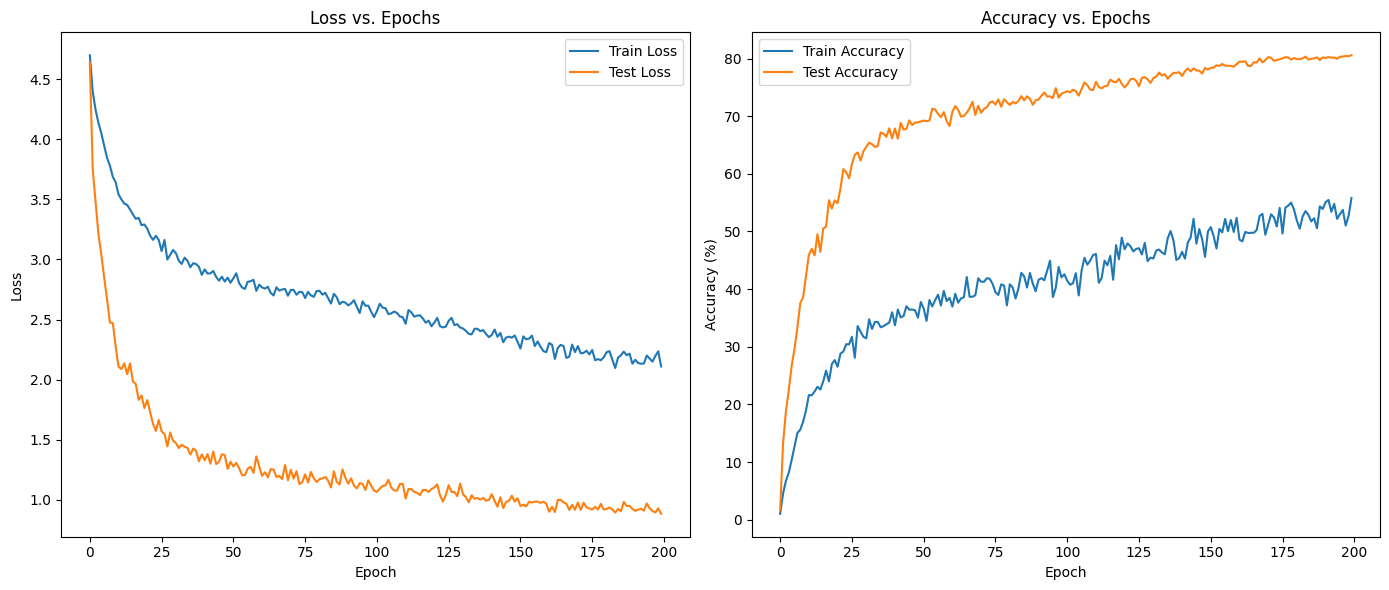


--- Analyzing the Best Model on the Test Set ---


Epoch 199 [Test]: 100%|██████████| 79/79 [00:03<00:00, 25.73it/s, acc=80.6, loss=0.884]


Final Test Accuracy of the Best Model: 80.57%

==================== Firing Rate of Each Monitored Layer ====================
Total layers monitored: 0

--------------------------------------------------------------------------------
You can copy the list below for energy calculation:
[]



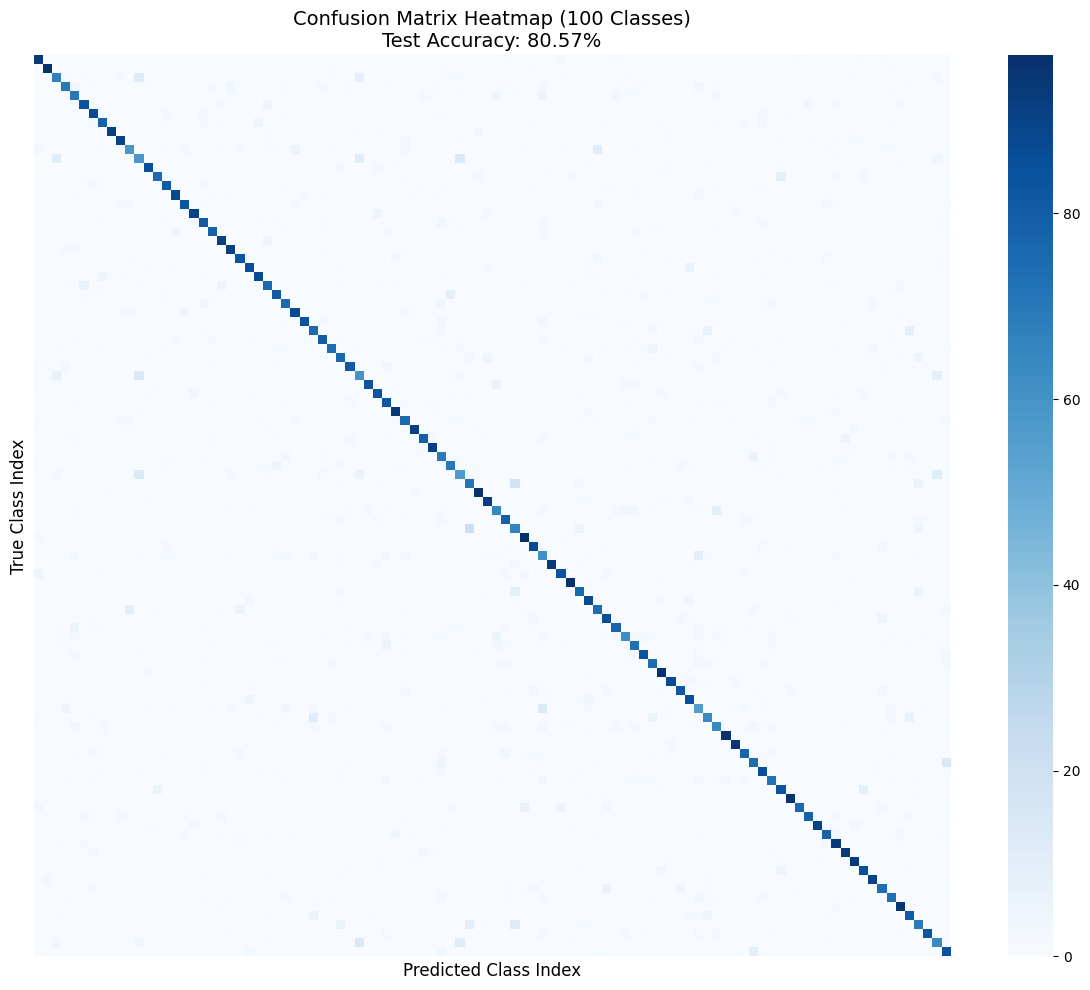

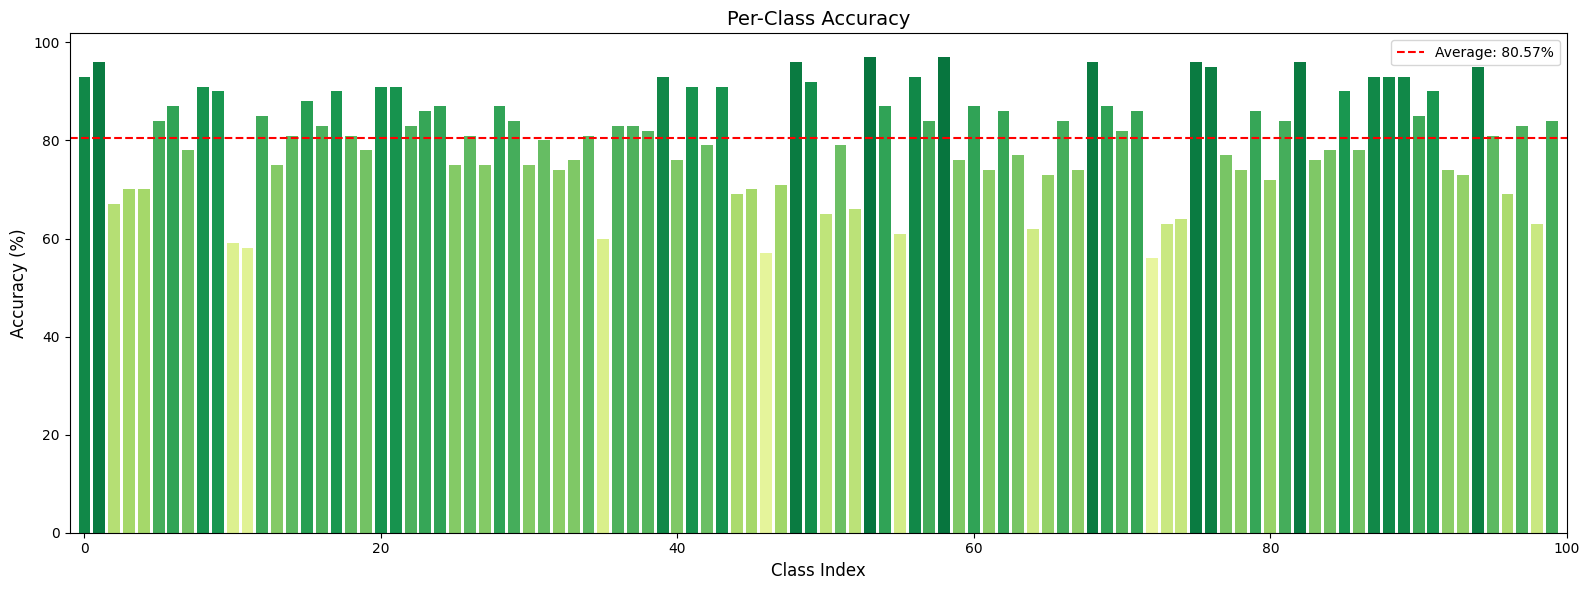

==================== Top-10 Most Confused Class Pairs ====================
True Class   Pred Class   Count   
-----------------------------------
52           47           21      
47           52           18      
11           46           14      
35           11           14      
78           99           14      
98           35           14      
46           11           13      
72           55           13      
2            11           12      
96           52           12      

==================== Per-Class Accuracy Summary ====================

Top-5 Worst Classes:
  Class  72: 56.00%
  Class  46: 57.00%
  Class  11: 58.00%
  Class  10: 59.00%
  Class  35: 60.00%

Top-5 Best Classes:
  Class  53: 97.00%
  Class  58: 97.00%
  Class  82: 96.00%
  Class   1: 96.00%
  Class  48: 96.00%



In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import os
import numpy as np

# --- 绘制 Loss 和 Accuracy 曲线 ---
# 定义历史记录文件的路径 (确保这个路径与训练时使用的路径一致)
checkpoint_path = os.path.join(log_dir, "checkpoint_latest.pth")
history_csv_path = os.path.join(log_dir, "training_history.csv")

# 检查文件是否存在，然后从CSV文件中读取数据
if os.path.exists(history_csv_path):
    print(f"Loading training history from: {history_csv_path}")
    history_df = pd.read_csv(history_csv_path)

    plt.figure(figsize=(14, 6))

    # 绘制 Loss 曲线
    plt.subplot(1, 2, 1)
    sns.lineplot(x="epoch", y="train_loss", data=history_df, label="Train Loss")
    sns.lineplot(x="epoch", y="test_loss", data=history_df, label="Test Loss")
    plt.title("Loss vs. Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # 绘制 Accuracy 曲线
    plt.subplot(1, 2, 2)
    sns.lineplot(x="epoch", y="train_acc", data=history_df, label="Train Accuracy")
    sns.lineplot(x="epoch", y="test_acc", data=history_df, label="Test Accuracy")
    plt.title("Accuracy vs. Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print(f"Error: Could not find the training history file at {history_csv_path}")

# 定义最佳模型文件的路径
best_model_path = os.path.join(log_dir, "best_model.pth")

if os.path.exists(best_model_path):
    print("\n--- Analyzing the Best Model on the Test Set ---")

    # 加载最佳模型的权重
    net.load_state_dict(torch.load(best_model_path, weights_only=False))

    _, final_test_acc, all_labels, all_preds = test(args.epochs - 1)

    # 打印最终的测试精度
    print(f"\nFinal Test Accuracy of the Best Model: {final_test_acc:.2f}%\n")

    # ==================== 混淆矩阵 (适配100类) ====================
    cm = confusion_matrix(all_labels, all_preds)

    # --- 方式1: 热力图 (不显示数字，只看颜色分布) ---
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm, cmap="Blues", cbar=True, xticklabels=False, yticklabels=False
    )  # 隐藏刻度标签
    plt.xlabel("Predicted Class Index", fontsize=12)
    plt.ylabel("True Class Index", fontsize=12)
    plt.title(
        f"Confusion Matrix Heatmap (100 Classes)\nTest Accuracy: {final_test_acc:.2f}%",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

    # --- 方式2: 每类准确率条形图 (Per-class Accuracy) ---
    # 计算每类的准确率
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    per_class_acc = np.nan_to_num(per_class_acc)  # 处理除零情况

    plt.figure(figsize=(16, 6))
    colors = plt.cm.RdYlGn(per_class_acc)  # 红黄绿渐变，低准确率红色，高准确率绿色
    plt.bar(range(args.num_classes), per_class_acc * 100, color=colors)
    plt.axhline(
        y=final_test_acc,
        color="r",
        linestyle="--",
        label=f"Average: {final_test_acc:.2f}%",
    )
    plt.xlabel("Class Index", fontsize=12)
    plt.ylabel("Accuracy (%)", fontsize=12)
    plt.title("Per-Class Accuracy", fontsize=14)
    plt.legend()
    plt.xlim(-1, args.num_classes)
    plt.tight_layout()
    plt.show()

    # --- 方式3: 打印Top-10最容易混淆的类别对 ---
    print("=" * 20 + " Top-10 Most Confused Class Pairs " + "=" * 20)
    # 将对角线置零（排除正确预测）
    cm_copy = cm.copy().astype(float)
    np.fill_diagonal(cm_copy, 0)

    # 找到最大的10个混淆值
    top_confused = []
    for _ in range(10):
        idx = np.unravel_index(np.argmax(cm_copy), cm_copy.shape)
        if cm_copy[idx] > 0:
            top_confused.append((idx[0], idx[1], int(cm_copy[idx])))
            cm_copy[idx] = 0
        else:
            break

    print(f"{'True Class':<12} {'Pred Class':<12} {'Count':<8}")
    print("-" * 35)
    for true_cls, pred_cls, count in top_confused:
        print(f"{true_cls:<12} {pred_cls:<12} {count:<8}")
    print("=" * 60 + "\n")

    # --- 方式4: 打印Top-5最差和最好的类别 ---
    print("=" * 20 + " Per-Class Accuracy Summary " + "=" * 20)
    sorted_indices = np.argsort(per_class_acc)

    print("\nTop-5 Worst Classes:")
    for idx in sorted_indices[:5]:
        print(f"  Class {idx:3d}: {per_class_acc[idx] * 100:5.2f}%")

    print("\nTop-5 Best Classes:")
    for idx in sorted_indices[-5:][::-1]:
        print(f"  Class {idx:3d}: {per_class_acc[idx] * 100:5.2f}%")
    print("=" * 60 + "\n")

else:
    print(f"\nError: Could not find the best model file at {best_model_path}")
    print(
        "Please make sure you have run the training cell first to generate the model file."
    )


In [8]:
# 释放未被引用的 CUDA 缓存
torch.cuda.empty_cache()
